In [85]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from ydata_profiling import ProfileReport

ModuleNotFoundError: No module named 'ydata_profiling'

In [16]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
chronic_kidney_disease = fetch_ucirepo(id=336) 
  
# data (as pandas dataframes) 
X = chronic_kidney_disease.data.features # 24 independent features 
y = chronic_kidney_disease.data.targets # Target column 
  
# metadata 
print(chronic_kidney_disease.metadata) 
  
# variable information 
print(chronic_kidney_disease.variables) 

{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

On  target column: <br> - ckd means Chronic Kidney Disease <br>
                     - not ckd: means not Chronic Kidney Disease

In [17]:
import pandas as pd
chronic_kidney_disease # Get only the dataframe which exist inside the features value
# Take a copy of the original X
df = X.copy()

# Create a new column to y in order to have everything in one dataset
df['target'] = y
# Display the first five rows
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [35]:
print(df.columns)

Index(['age', 'blood_press', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume', 'white_blood_cell_cnt',
       'red_blood_cell_cnt', 'hypertension', 'diabetes_mellitus',
       'coronary_artery_disease', 'appetite', 'pedal_edema', 'anemia',
       'target'],
      dtype='object')


In [36]:
df.describe()

,age,blood_press,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum creatinine,sodium,potassium,hemoglobin,packed_cell_volume,white_blood_cell_cnt,red_blood_cell_cnt
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_press              388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  hemoglobin               3

In [29]:
df.duplicated().sum()

np.int64(0)

In [59]:
df.isna().sum()

age                          9
blood_press                 12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum creatinine            17
sodium                      87
potassium                   88
hemoglobin                  52
packed_cell_volume          71
white_blood_cell_cnt       106
red_blood_cell_cnt         131
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       1
target                       0
dtype: int64

Since these are clinical data we need to further investigate the null values.

In [19]:
# Copy the dataset 
df = df.copy()

# We need to rename the columns since we cannot understand what each column means
df.rename(columns={'bp': 'blood_press', 'sg': 'specific_gravity',
                   'al':'albumin','su':'sugar',
                   'rbc':'red_blood_cells','pc':'pus_cell',
                   'pcc':'pus_cell_clumps','ba':'bacteria',
                   'bgr':'blood_glucose_random','bu':'blood_urea','sc':'serum creatinine',
                   'sod':'sodium','pot':'potassium','hemo':'hemoglobin',
                   'pcv':'packed_cell_volume','wc':'white_blood_cell_cnt','rc':'red_blood_cell_cnt',
                   'htn':'hypertension','dm':'diabetes_mellitus','cad':'coronary_artery_disease',
                   'appet':'appetite','pe':'pedal_edema','ane':'anemia', 'wbcc':'white_blood_cell_cnt', 'rbcc':'red_blood_cell_cnt',
                   'class':'class','target':'target'}, inplace=True)

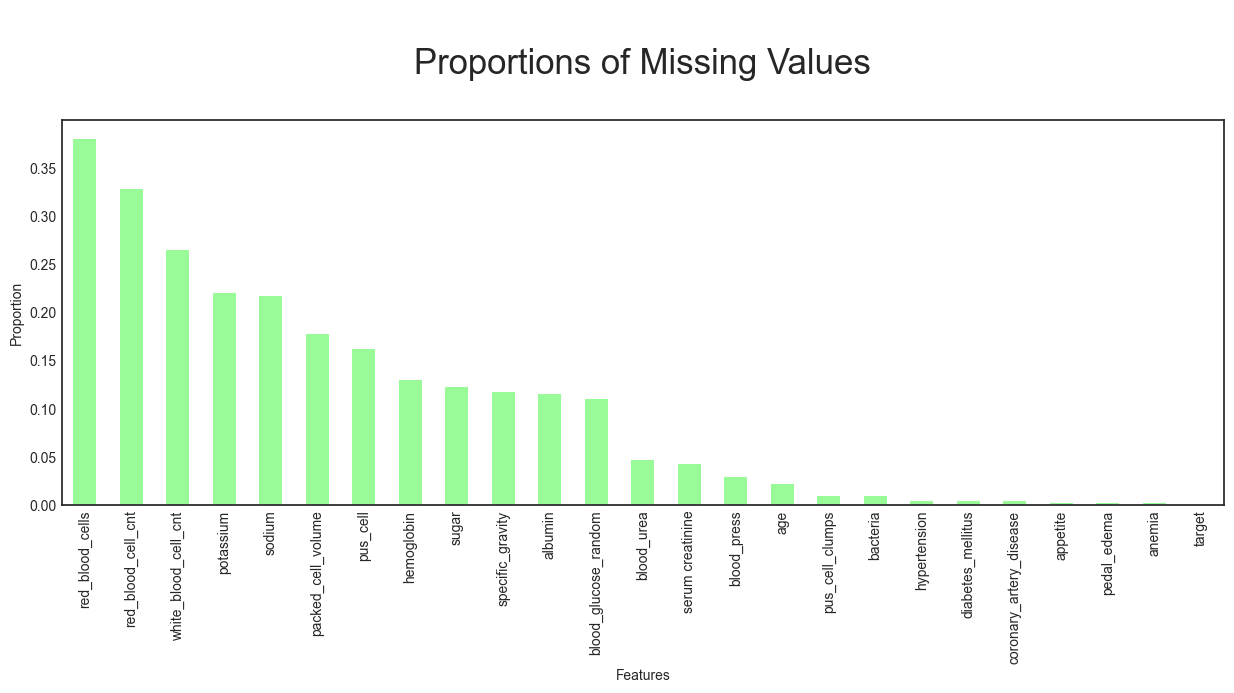

In [64]:
# missing values in ascending order 
missing = df.isna().sum().sort_values(ascending = False)

# plot the proportion of missing values
plt.figure(figsize=(15,5))
(missing/400).plot(kind="bar", color="palegreen") # we divide by 400 hundred to get only the proportion. (400 is the total records)
plt.title('\nProportions of Missing Values\n', fontsize=25)
plt.ylabel("Proportion")
plt.xlabel("Features")
plt.show()


In [22]:
# Extracting categorical and numerical columns
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

#  Step 1: Univariate Analysis

In [39]:
df['target'].value_counts()

target
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

That \t in ckd\t is just an extra tab character that was accidentally included in the dataset. It’s not part of the actual label, so it needs to be cleaned.

In [40]:
# Remove extra whitespace, including tabs, from the target column
df['target'] = df['target'].str.strip()
print(df['target'].value_counts())

target
ckd       250
notckd    150
Name: count, dtype: int64


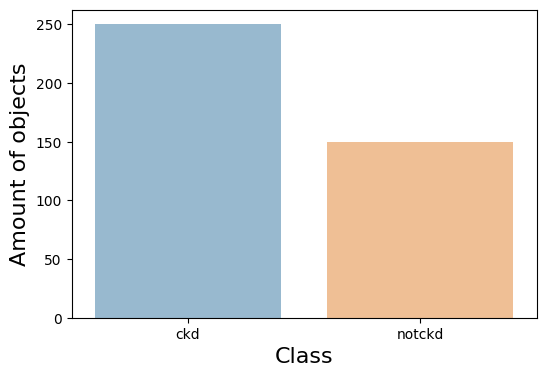

In [45]:
# Plot the target 's distribution
plt.figure(figsize=(6,4))
label_counts = df['target'].value_counts().reset_index()
label_counts.columns = ['target', 'Count']
sns.barplot(data=label_counts, x='target', y='Count', hue= 'target',alpha=0.5)
plt.ylabel('Amount of objects', fontsize=16)
plt.xlabel('Class', fontsize=16)
plt.tight_layout
plt.show();

As we can see from the above the classes are not equally distributed.

In [69]:
# Display the rows with null values
df1 = df[df.isna().any(axis=1)]
df1

,age,blood_press,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,hemoglobin,packed_cell_volume,white_blood_cell_cnt,red_blood_cell_cnt,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,11.3,38.0,6000.0,NaN,no,no,no,good,no,no
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,11.6,35.0,7300.0,4.6,no,no,no,good,no,no
5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,74.0,...,12.2,39.0,7800.0,4.4,yes,yes,no,good,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,65.0,70.0,1.025,0.0,0.0,NaN,NaN,notpresent,notpresent,85.0,...,16.1,43.0,9600.0,4.5,no,no,no,good,no,no
363,67.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,99.0,...,17.8,44.0,5900.0,5.2,no,no,no,good,no,no
365,24.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,93.0,...,NaN,NaN,10700.0,6.3,no,no,no,good,no,no
378,71.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,NaN,...,15.2,42.0,7700.0,5.5,no,no,no,good,no,no


In [25]:
df['albumin'].value_counts()

albumin
0.0    199
1.0     44
3.0     43
2.0     43
4.0     24
5.0      1
Name: count, dtype: int64

In [21]:
df['red_blood_cells'].isnull().sum()

np.int64(152)

- Numerical Columns

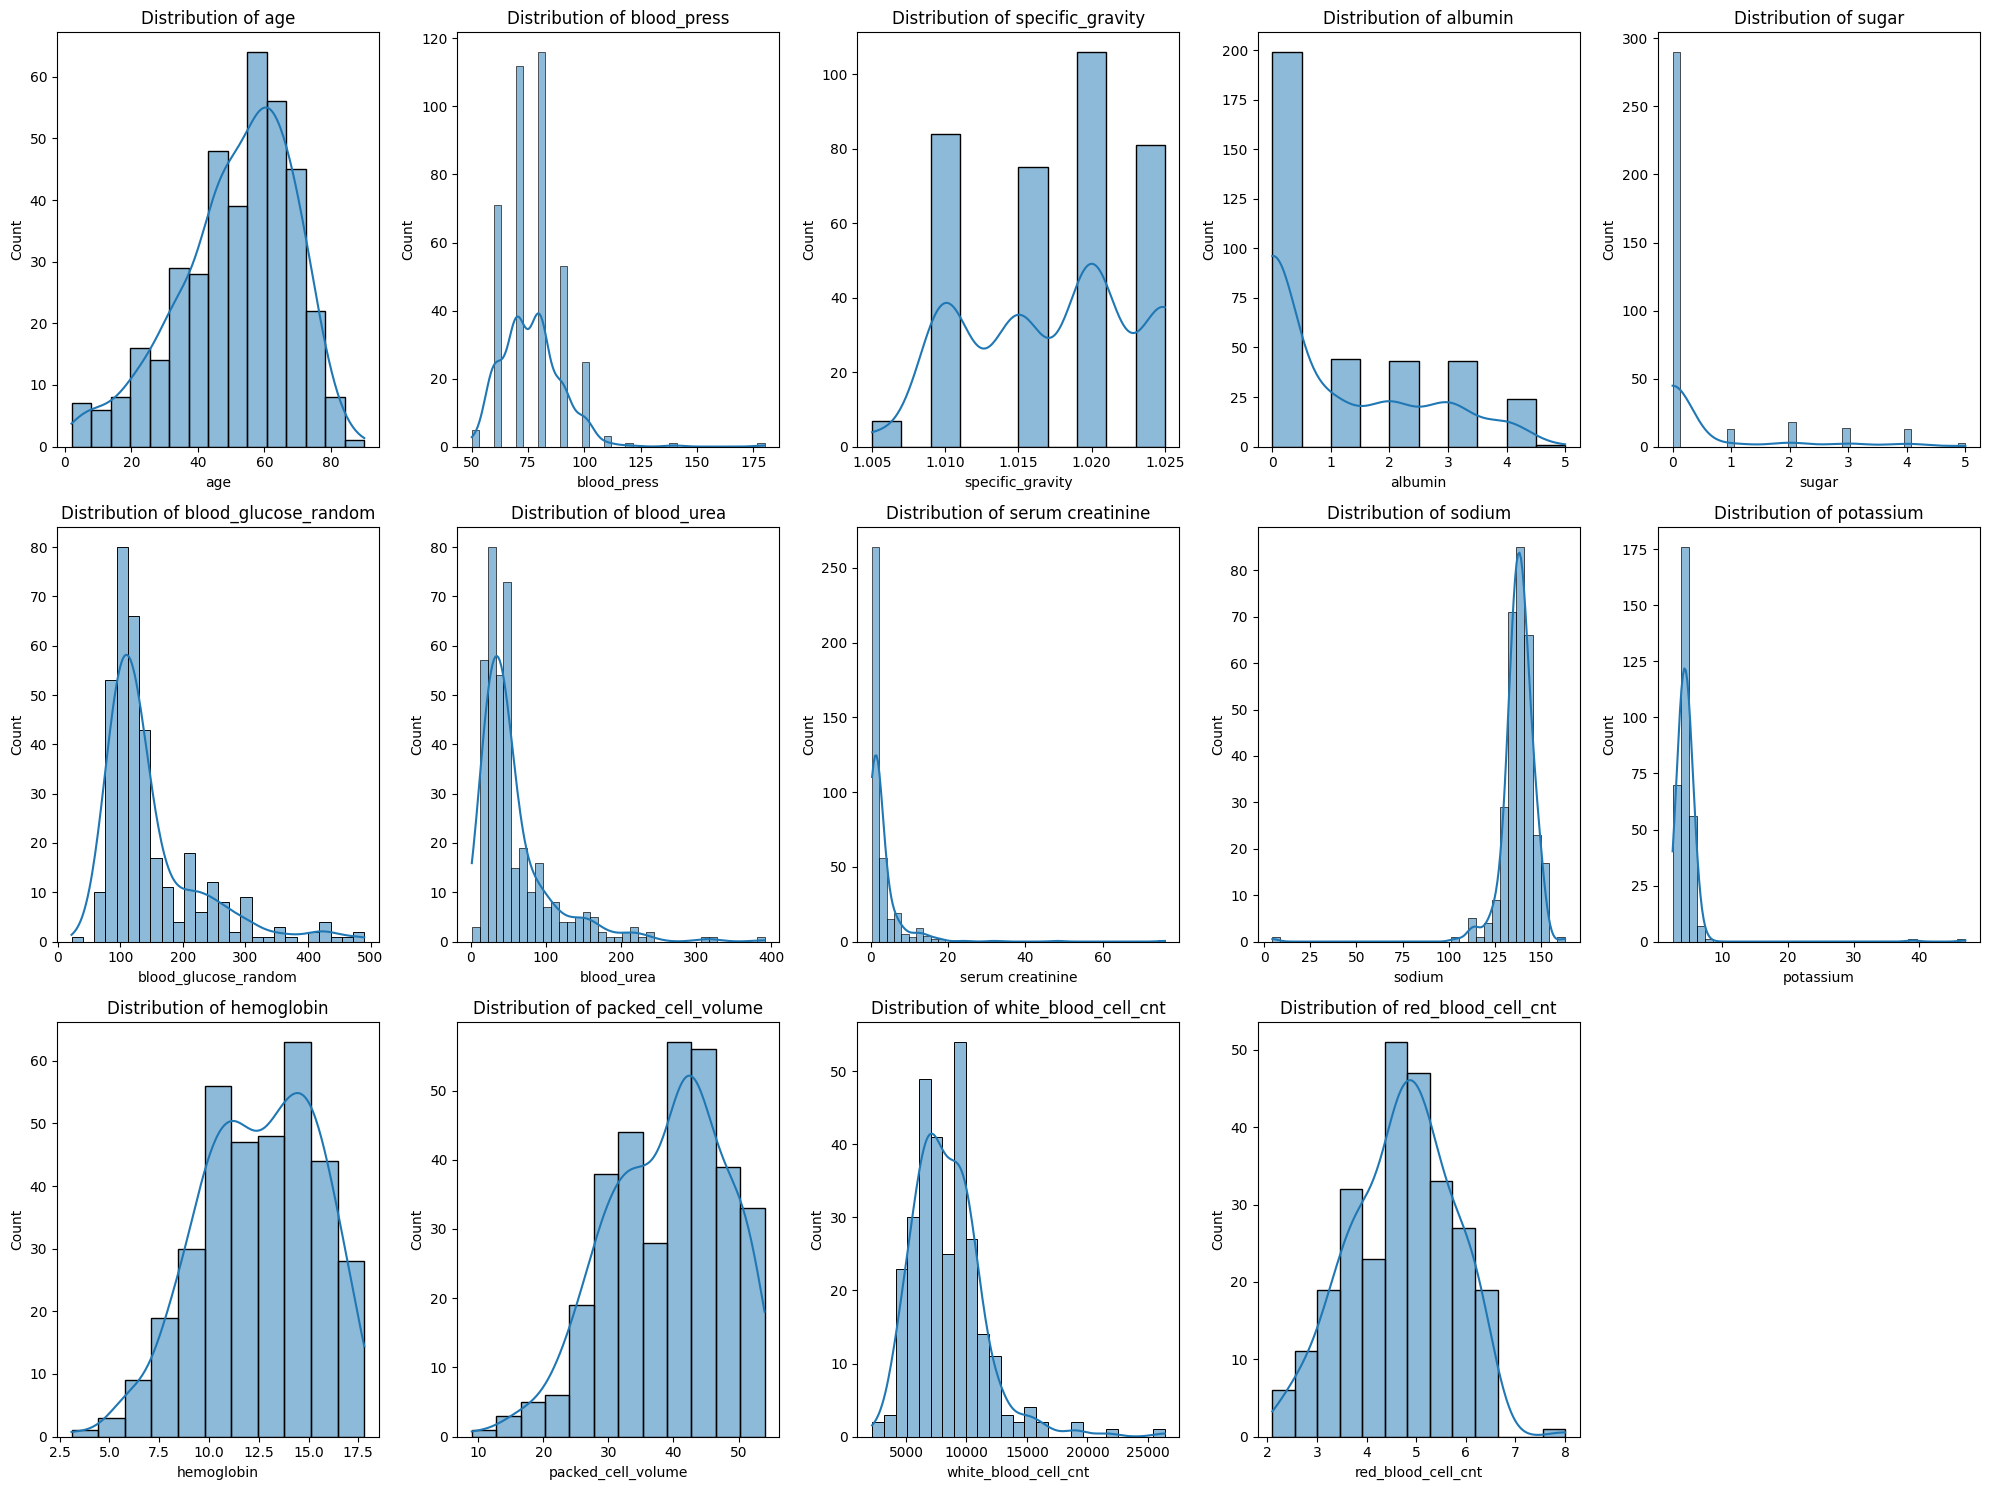

In [23]:
# checking numerical features distribution
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in num_cols:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.histplot(df[column],kde=True)
        plt.xlabel(column)
        plt.title(f'Distribution of {column}')
    plotnumber += 1

plt.tight_layout()
plt.show()

From the above diagram we can understand the follow:
- blood_urea is positive skewed. That means most of the values are clustered around the left tail of the distribution while the right tail is longer.

- serum_creatinine is highly positive skewed.The most data points are clustered in the left with a few high-value outliers on the right.

- sodium is highly negative skewed.

- potassium is highly positive skewed.

We will do further investigation for each and every variable.

In [ ]:
# Create a function to plot each and every variable on univariate analysis
def dist_box(col):
    fig = plt.figure(figsize =(10, 7))
    fig, ax = plt.subplots(1,2, figsize = (15,5))
    sns.histplot(x= col, data = df, ax = ax[0],kde=True)
    sns.boxplot(x=col, data = df,color='purple',ax = ax[1])
    fig.suptitle(f'{col} Distribution', fontsize=16)
    plt.tight_layout()
    plt.show()

# Age

<Figure size 1000x700 with 0 Axes>

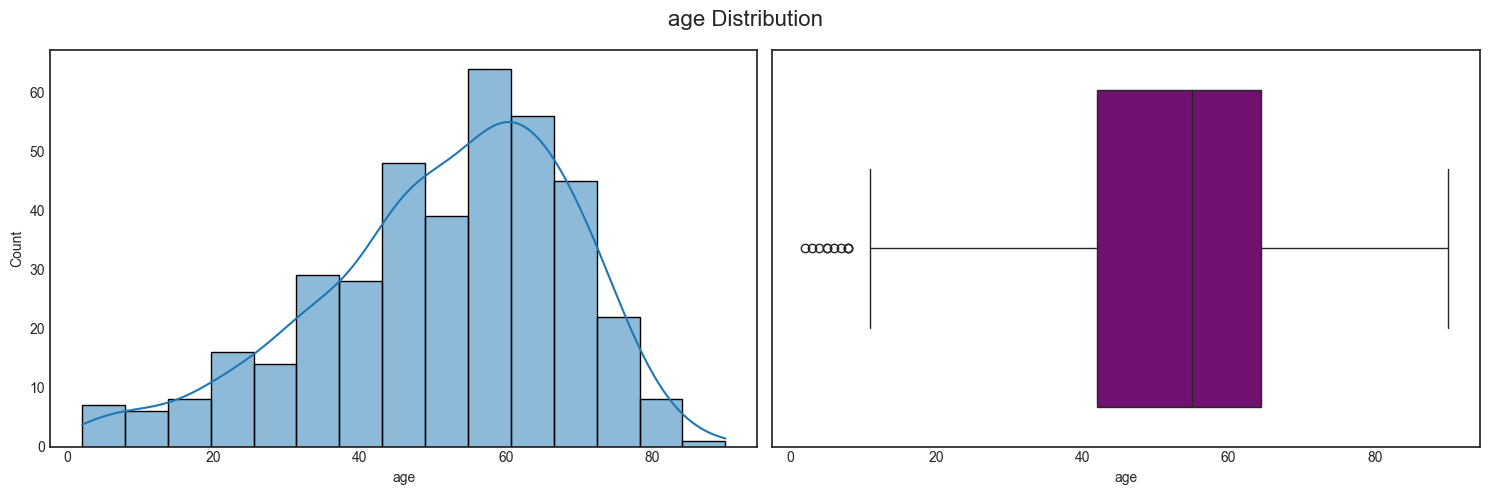

In [82]:
dist_box('age')

In [77]:
df['age'].describe()

count    391.000000
mean      51.483376
std       17.169714
min        2.000000
25%       42.000000
50%       55.000000
75%       64.500000
max       90.000000
Name: age, dtype: float64

In [79]:
df['age'].median()

np.float64(55.0)

In [78]:
df['age'].isna().sum()

np.int64(9)

In [84]:
# We will fill the missing values of this with mean.
df["age"].fillna(df["age"].mean(), inplace=True)

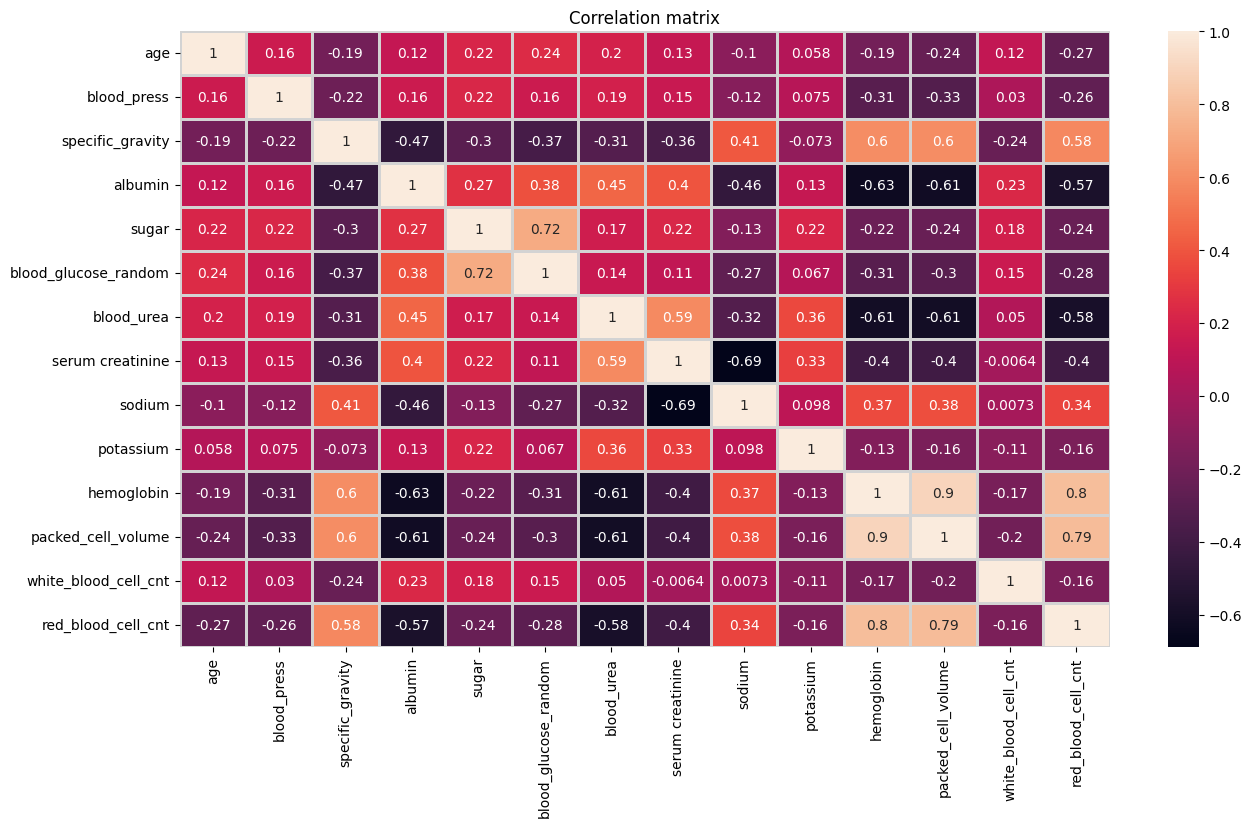

In [56]:
# Correlation matrix only for numerical data
plt.figure(figsize = (15, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot = True, linewidths = 2, linecolor = 'lightgrey')
plt.title('Correlation matrix')
plt.show()

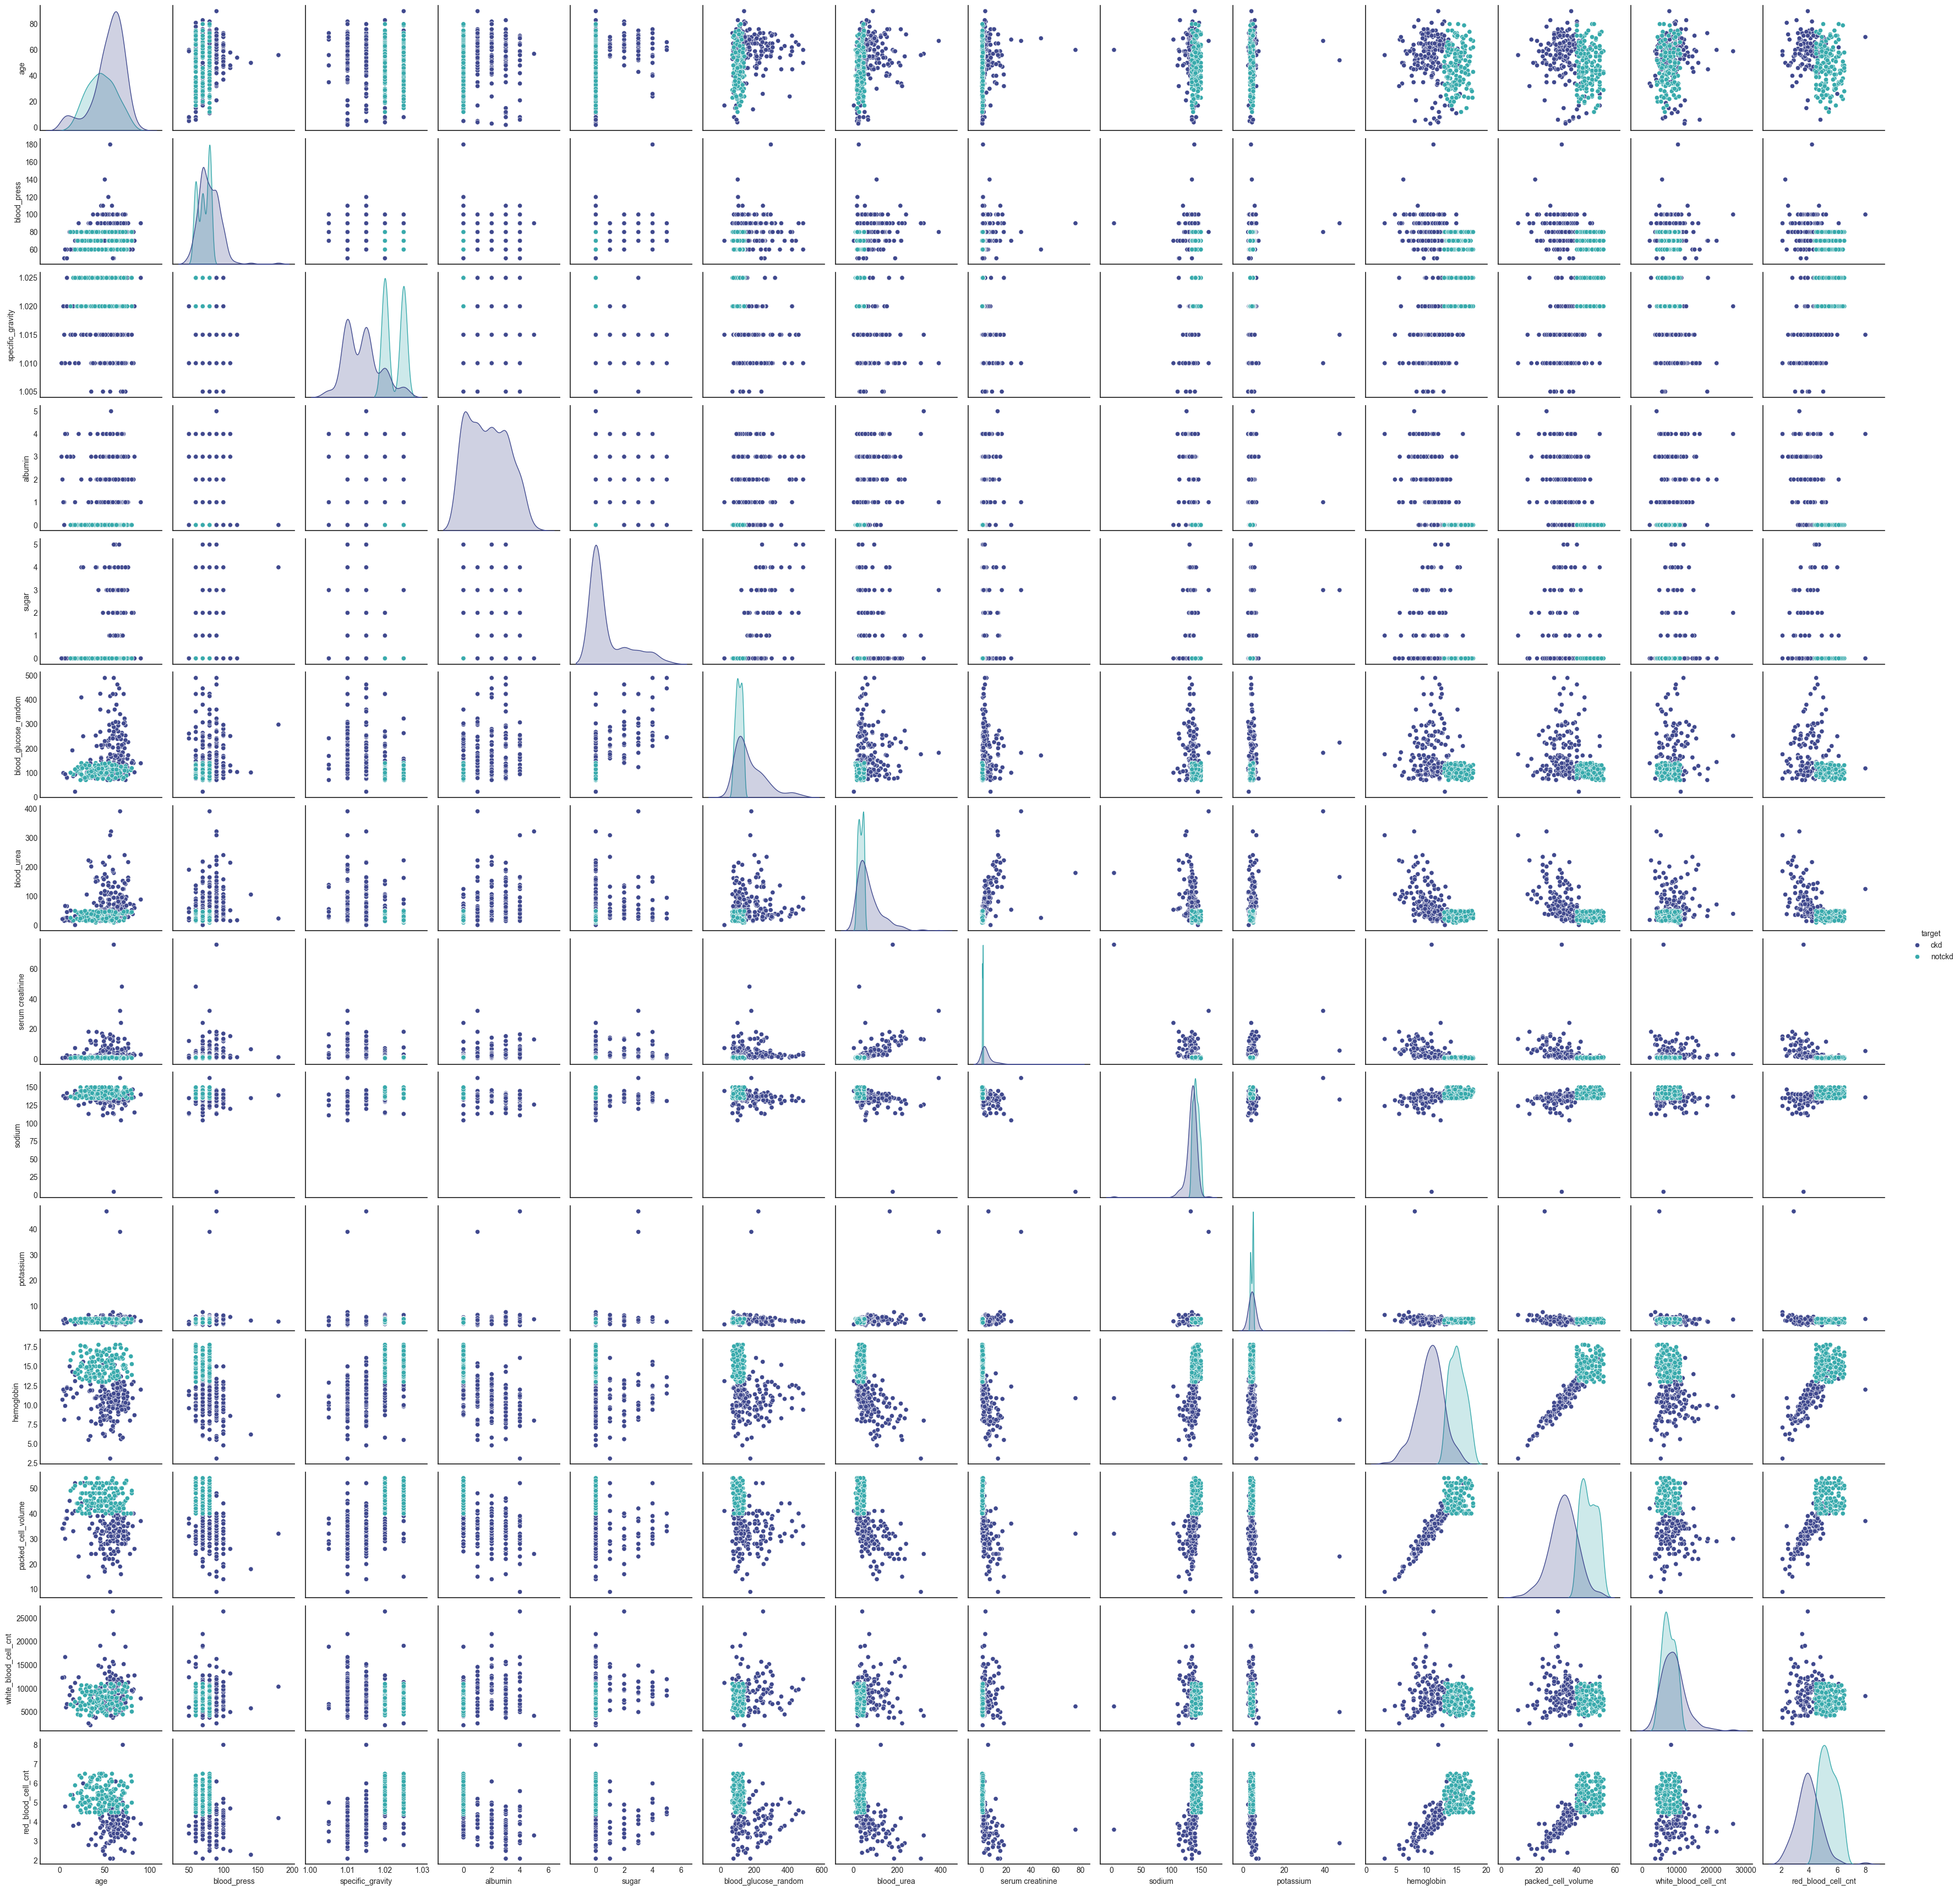

In [58]:
plt.style.use('seaborn-v0_8-white')

# Drop 'person_id' and plot pairplot colored by sleep_disorder
sns.pairplot(data=df, 
             hue='target', 
             palette='mako')

plt.show()

In [49]:
for col in cat_cols:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("-" * 30)

Column: red_blood_cells
red_blood_cells
normal      201
abnormal     47
Name: count, dtype: int64
------------------------------
Column: pus_cell
pus_cell
normal      259
abnormal     76
Name: count, dtype: int64
------------------------------
Column: pus_cell_clumps
pus_cell_clumps
notpresent    354
present        42
Name: count, dtype: int64
------------------------------
Column: bacteria
bacteria
notpresent    374
present        22
Name: count, dtype: int64
------------------------------
Column: hypertension
hypertension
no     251
yes    147
Name: count, dtype: int64
------------------------------
Column: diabetes_mellitus
diabetes_mellitus
no      260
yes     137
\tno      1
Name: count, dtype: int64
------------------------------
Column: coronary_artery_disease
coronary_artery_disease
no     364
yes     34
Name: count, dtype: int64
------------------------------
Column: appetite
appetite
good    317
poor     82
Name: count, dtype: int64
------------------------------
Column: peda

KeyError: 'serum_creatinine'

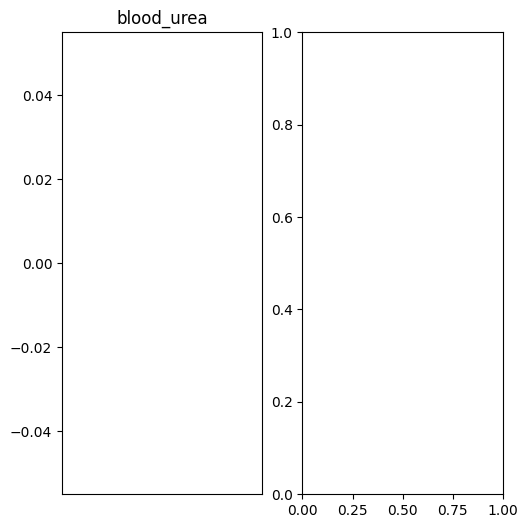

In [9]:
import matplotlib.pyplot as plt

features = [
    'blood_urea',
    'serum_creatinine',
    'sodium',
    'potassium',
    'white_blood_cell_cnt'
]

plt.figure(figsize=(15, 6))

for i, col in enumerate(features, 1):
    plt.subplot(1, 5, i)
    plt.boxplot(df[col])
    plt.title(col)
    plt.xticks([])

plt.tight_layout()
plt.show()

In [ ]:
# checking numerical features distribution

plt.figure(figsize = (20, 15))
plotnumber = 1

for column in num_cols:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column)
        
    plotnumber += 1

plt.tight_layout()
plt.show()

In [32]:
num_cols

['age',
 'blood_press',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum creatinine',
 'sodium',
 'potassium',
 'hemoglobin',
 'packed_cell_volume',
 'white_blood_cell_cnt',
 'red_blood_cell_cnt']

In [31]:
cat_cols

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'pedal_edema',
 'anemia']